# Assignment 2

## *Does a job training program improve the earnings of disadvantaged workers?*

In [6]:
# Silent warnings
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pylab

# Data
import pandas as pd
from sklearn import tree
from sklearn import metrics
from sklearn import neighbors
from sklearn import ensemble


# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('darkgrid')
plt.style.use('ggplot')

<h2>Introduction</h2>

<p><strong>Business Context.</strong> In the 1980s, Robert Lalonde conducted a study to evaluate the effects of training programs on labour workers. He observed the characteristic background data of the individuals involved. Several of them were selected for enrollment in the job training program (the National Supported Work Demonstration). The training program specifically targeted unemployed women, ex-drug addicts, ex-criminal offenders, and high school dropouts.</p>
<p><img src="data/trainingfailsmain.jpg" width="550" alt="Labour Training"></p>
<p>The Department of Labor is interested in digging deeper into this data and coming up with some actionable insights in order to raise the earnings of disadvantaged workers. They have contracted you as a data science consultant to assist them with this task.</p>
<p><strong>Business Problem.</strong> Your goal is to evaluate <strong>whether the job training program <em>causes</em> the earnings of disadvantaged workers to go up</strong>.</p>
<p><strong>Analytical Context.</strong> In this case we will continue our discussion of causal inference. We will study the importance of covariate balance and explore how to perform matching to get this balance. We will leverage a lot of the new classification models we have learned for this purpose.</p>

<h2>Examining the data</h2>
<p>The Lalonde dataset provides information on annual income for workers who enroll in the training workshop and those who did not enroll in the year subsequent to training. The outcome of interest is <code>re78</code> in which we want to know if there was an increase in earnings in 1978:</p>
<ol>
<li><strong>age</strong>: age in years</li>
<li><strong>educ</strong>: years of schooling</li>
<li><strong>black</strong>: indicator variable for blacks</li>
<li><strong>hisp</strong>: indicator variable for Hispanics</li>
<li><strong>married</strong>: indicator variable for martial status</li>
<li><strong>nodegr</strong>: indicator variable for high school diploma</li>
<li><strong>re74</strong>: real earnings in 1974</li>
<li><strong>re75</strong>: real earnings in 1975</li>
<li><strong>re78</strong>: real earnings in 1978 - this is the outcome of interest</li>
<li><strong>treat</strong>: an indicator variable for treatment status</li>
</ol>

In [10]:
lalonde_df = pd.read_csv('lalonde.csv', index_col=0)
lalonde_df.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
NSW1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
NSW2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
NSW3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
NSW4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
NSW5,1,33,8,1,0,0,1,0.0,0.0,289.7899


<h3>Exercise 1:</h3>
<h4>1.1</h4>
<p>Provide summary statistics for all the variables in the dataset. What can you say about the average income of the population throughout the years? What percentage of the population saw a decrease in income from 1974 to 1975? What do you think happened in 1975?</p>

**Answer.**

-------

In [14]:
#Summary Statistics for all variables in dataset
summary = lalonde_df.describe()
summary

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.301303,27.363192,10.268730,0.395765,0.117264,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,0.459198,9.881187,2.628325,0.489413,0.321997,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,0.000000,25.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,1.000000,32.000000,12.000000,1.000000,0.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,1.000000,55.000000,18.000000,1.000000,1.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [15]:
#Observe the percentage of the population that saw decrease in income in 1975, compared to 1974
decrease = ((sum(lalonde_df['re75'] < lalonde_df['re74']))/614)*100
decrease

46.416938110749186

While observing the 'mean' for the columns **'re74'**, **'re75'**, and **'re78'**, we can see that the average income in 1974 was approximately **\$4557**, but it suddenly dropped to **\$2184** in 1975. This implies that many individuals received a substantial decrease in income. Then, from 1975 to 1978, there was an increase in average income from **\$2184** to **\$6792**. 

From the above calculation, approximately 46% of the population experienced a decline in earnings in 1975. This is a large percentage of the population - almost half. This implies that there may have been an economic crisis/hardship (e.x recession) during that period. Many individuals may have experienced job loss or significant wage cuts. 

<h4>1.2</h4>
<p>What percentage of the workers in our dataset are in the treatment group? Find the difference in means and medians of earnings between the control group and the treatment group. Is the difference of means statistically significant?</p>
<p><strong>Note:</strong> Remember that the <em>treatment and control groups</em> correspond to the sets of workers that were enrolled and not enrolled in the job training program, respectively. We can check if a worker is part of the treatment group by simply checking the value of the  <code>treat</code> column.</p>

**Answer.**

In [19]:
#Finding the percentage of workers in treatment group
proportion_treat = lalonde_df['treat'].sum()/len(lalonde_df)
proportion_treat

0.30130293159609123

In [20]:
#Finding median and mean for treatment group
treatment = lalonde_df[lalonde_df['treat'] == 1]

treat_mean74 = treatment['re74'].mean()
treat_med74 = treatment['re74'].median()

treat_mean75 = treatment['re75'].mean()
treat_med75 = treatment['re74'].median()

treat_mean78 = treatment['re78'].mean()
treat_med78 = treatment['re74'].median()

In [21]:
#Finding median and mean for control group
control = lalonde_df[lalonde_df['treat'] == 0]

control_mean74 = control['re74'].mean()
control_med74 = control['re74'].median()

control_mean75 = control['re75'].mean()
control_med75 = control['re74'].median()

control_mean78 = control['re78'].mean()
control_med78 = control['re74'].median()

In [22]:
meanDiff74= treat_mean74 - control_mean74
meanDiff75= treat_mean75 - control_mean75
meanDiff78= treat_mean78 - control_mean78

medDiff74= treat_med74 - control_med74
medDiff75= treat_med75 - control_med75
medDiff78= treat_med78 - control_med78

In [23]:
#P-tests to determine whether the differences are statistically significant

t_stat74, p_value74 = scipy.stats.ttest_ind(lalonde_df.loc[lalonde_df['treat'] == 1, 're74'],
                                      lalonde_df.loc[lalonde_df['treat'] == 0, 're74'],
                                      equal_var=False)  
print(f"Difference in means 1974: {meanDiff74:.2f}")
print(f"Difference in medians 1974: {medDiff74:.2f}")
print(f"T-statistic: {t_stat74:.2f}, P-value: {p_value74:.4f}")
print(" ")

t_stat75, p_value75 = scipy.stats.ttest_ind(lalonde_df.loc[lalonde_df['treat'] == 1, 're75'],
                                      lalonde_df.loc[lalonde_df['treat'] == 0, 're75'],
                                      equal_var=False)
print(f"Difference in means 1975: {meanDiff75:.2f}")
print(f"Difference in medians 1975: {medDiff75:.2f}")
print(f"T-statistic: {t_stat75:.2f}, P-value: {p_value75:.4f}")
print(" ")

t_stat78, p_value78 = scipy.stats.ttest_ind(lalonde_df.loc[lalonde_df['treat'] == 1, 're78'],
                                      lalonde_df.loc[lalonde_df['treat'] == 0, 're78'],
                                      equal_var=False)
print(f"Difference in means 1978: {meanDiff78:.2f}")
print(f"Difference in medians 1978: {medDiff78:.2f}")
print(f"T-statistic: {t_stat78:.2f}, P-value: {p_value78:.4f}")
print(" ")

Difference in means 1974: -3523.66
Difference in medians 1974: -2547.05
T-statistic: -7.25, P-value: 0.0000
 
Difference in means 1975: -934.43
Difference in medians 1975: -2547.05
T-statistic: -3.28, P-value: 0.0012
 
Difference in means 1978: -635.03
Difference in medians 1978: -2547.05
T-statistic: -0.94, P-value: 0.3491
 


In summary, our above findings show the following:
* Approximately 30% of the dataset is in the treatment group.
* The difference in mean and medians of earnings in 1974 (respectively) are: -3523.66, -2547.05
* The difference in mean and medians of earnings in 1975 (respectively) are: -934.43, -2547.05
* The difference in mean and medians of earnings in 1978 (respectively) are: -653.03, -2547.05
* The difference in means in the years 1974 and 1975 are statistically significant because the p-values in the test are less than 0.05.
* The difference in the mean for the year 1978 is not statistically significant because the p-value is 0.3491, which is greater than 0.05. 

-------

<h4>1.3</h4>
<p>Does your previous result mean that the treatment had a negative impact? Why or why not?</p>

**Answer.**

When calculating the differences, I subtracted the mean/median earnings of the control group FROM the mean/median earnings of the treatment group. We found all the differences were negative this implies the mean/median earnings for the control group is **higher** than the treatment group. 

Although the mean/median earnings are higher for the control group, this **does not** imply that the treatment had a negative impact. This demonstrates there is a correlation between the treatment and lower-income earnings. This correlation may be impacted by other factors and hidden biases in the data. For instance, the individuals may have signed up to participate in the (treatment) training program *because* they are disadvantaged/have a low income. 

We are unable to say that the treatment directly caused the lower earnings. 

-------

## Assessing balance between the control group and the treatment group

Suppose we want to assess whether balance has been achieved for a particular feature $x = age$. That is, we would like to check whether the treatment and control groups have similar distributions of ages. We can look at **Standardized Mean Differences (SMD)**, which is calculated as follows: let $(\bar{x}_t,s_t^2)$ and $(\bar{x}_c, s_c^2)$ denote the mean and variance corresponding to the treatment and control groups of the particular feature of interest. Then, the SMD is defined as the value:

$$\mathrm{SMD}(x)=\frac{\bar{x}_{t}-{\bar{x}_{c}}}{\sqrt{\frac{s^{2}_{t} + s^{2}_{c}}{2}}}.$$

We can calculate the SMD for every feature. If our calculated SMD is 1, then that means there is a 1 standard deviation difference in means. The benefit of having standard deviation in the denominator is that this number becomes insensitive to the scale of the feature. 

After computing this measurement for all of our features, there is a rule of thumb that is commonly used to determine whether that feature is balanced or not (similar to the idea of using 0.05 as a threshold for $p$ - values):

1. **SMD < 0.1**: We say that the feature is balanced. In general, for a **randomized trial**, the SMD for all of the covariates should typically fall into this bucket.
2. **SMD is between 0.1 and 0.2**:  Not necessarily balanced, but small enough that people are usually not too worried about them. Sometimes, even after performing matching, there might still be a few covariates whose SMD falls in this range.
3. **SMD > 0.2**: Values that are greater than this threshold are considered seriously imbalanced.

<h3>Exercise 2:</h3>
<h4>2.1</h4>
<p>Assess covariate balance between the treatment and control groups. What features (covariates) are imbalanced between the control group and the treatment group in this dataset?</p>

**Answer.**

In [33]:
lalonde_df.columns

Index(['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree',
       're74', 're75', 're78'],
      dtype='object')

In [34]:
features = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78'] 

for feat in features:
    treatment_mean = lalonde_df.loc[lalonde_df['treat'] == 1, feat].mean()
    control_mean = lalonde_df.loc[lalonde_df['treat'] == 0, feat].mean()

    treatment_var = lalonde_df.loc[lalonde_df['treat'] == 1, feat].var()
    control_var= lalonde_df.loc[lalonde_df['treat'] == 0, feat].var()

    denom = np.sqrt((treatment_var + control_var)/2)
    smd = (treatment_mean - control_mean)/denom

    if smd < 0.1:
        print(f'SMD for {feat}: {smd} - Randomized')
    elif (0.1<smd<0.2):
        print(f'SMD for {feat}: {smd} - Slightly Imbalanced')
    elif smd > 0.2:
        print(f'SMD for {feat}: {smd} - Severely Imbalanced')

SMD for age: -0.24190362292609968 - Randomized
SMD for educ: 0.04475508511087092 - Randomized
SMD for black: 1.6677188107185188 - Severely Imbalanced
SMD for hispan: -0.2769395965062945 - Randomized
SMD for married: -0.7194919624729041 - Randomized
SMD for nodegree: 0.23504820466514978 - Severely Imbalanced
SMD for re74: -0.5957515910049512 - Randomized
SMD for re75: -0.287002108742533 - Randomized
SMD for re78: -0.08370809386395259 - Randomized


From our above findings we can conclude the following:
* The variables: *age, education, hispanic, married, re74, re75,* and *re78* are all randomized
* The variables we should look into in the dataset are: *black* and *nodegree* - the data is very unbalanced for these features

Overall, while most of the covariates are balanced, the severe imbalance in black and nodegree implies these variables could have a significant impact on the results. These imbalances will need to be addressed to determine the impact of the treatment.

-------

<h4>2.2</h4>
<p>Make plots which show the histograms for both the treatment and control groups of the imbalanced covariates.</p>

**Answer.**

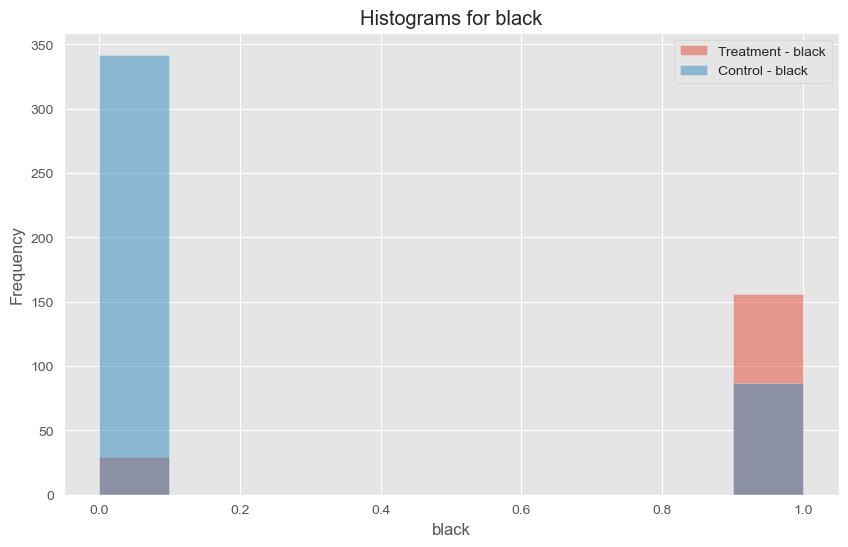

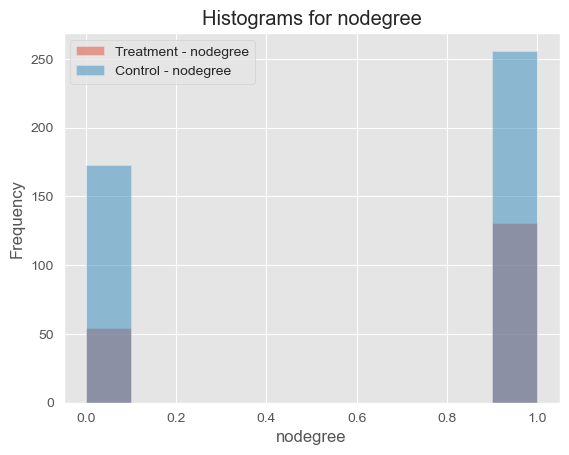

In [39]:
features = ['black', 'nodegree']

plt.figure(figsize=(10, 6))
for feat in features:
    #treatment group
    plt.hist(lalonde_df.loc[lalonde_df['treat'] == 1, feat], alpha=0.5, label=f'Treatment - {feat}')
    #control group
    plt.hist(lalonde_df.loc[lalonde_df['treat'] == 0, feat], alpha=0.5, label=f'Control - {feat}')

    # Add labels and title
    plt.title(f'Histograms for {feat}')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()


-------

<h2>Propensity score matching using logistic regression</h2>

<p>In order to balance the covariates of the control and treatment groups, we will use <strong>matching</strong>. Remember that we used matching in Case 7.5 to balance a population of prisoners to evaluate the effectiveness of a program aiming to reduce recidivism. Thus, the situation here is quite similar.</p>
<p>In Case 7.5 we used the <em>Euclidean distance</em> on the sample data to create the matching: for each individual of the treatment group, we would find the closest (in Euclidean distance) individual in the control group to match on. Although this method is attractive in general, we may have instances in which the balancing of some particular feature is more important than others. Say the employment program was aiming to create a positive impact within the Hispanic community and a higher proportion of individuals in the treatment group were Hispanic. The Euclidean distance would not take this into account, and we may end up comparing the effect of the treatment between Hispanics and other ethnicities.</p>
<p>We can alleviate this issue by using a metric that takes into account the characteristics of the treatment group. In this context, a metric called the <strong>propensity score</strong> helps us do the matching on select features in an efficient way. The key idea is that <em>the features that are correlated with the probability of a worker being selected into the treatment group affect our causal results</em>. A propensity score is this probability. The propensity score for subject $i$, denoted as $\pi_i$ is defined as:</p>
<p>$\pi_i$ = P(Subject $i$ is given training given their features $X_i$)</p>
<p>As an example, if a person had a propensity score of 0.3, that would mean that given their particular covariates, there was a 30% chance that they were placed in the treatment group. We can calculate this score by fitting a classification model to our data, where the input features are our covariates, and the output is whether that person was part of the treatment group or not.</p>

<h3>Exercise 3:</h3>
<h4>3.1</h4>
<p>Estimate the propensity scores using a logistic regression. Build a logistic regression model where the outcome variable is whether a subject was in the treatment group or not, and the covariates are all the other variables except <code>re78</code>. How would you interpret the predicted values output by the model? </p>

**Answer.**

In [45]:
lalonde_df.columns

Index(['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree',
       're74', 're75', 're78'],
      dtype='object')

In [46]:
log_model = lalonde_df.copy()
log_model['Intercept'] = 1
Variables = ['Intercept','age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

logit = sm.Logit(log_model['treat'], log_model[Variables])
logit_res = logit.fit()

Optimization terminated successfully.
         Current function value: 0.397267
         Iterations 7


The predicted values output by the model represent the propensity scores for each individual. These scores indicate the probability that an individual will be assigned to the treatment group based on their covariates (e.g. age, education, no degree, married, etc).
Individuals with higher propensity scores are more likely to be assigned to the treatment group based on their covariates. In contrast, individuals with lower propensity scores have a lower probability of being assigned to the treatment group, based on their covariates.

-------

<h4>3.2</h4>
<p>Use <code>.predict()</code>  to obtain the propensity scores of individuals in our dataset. Save the the results with the name <code>pscore_logit</code> (these will be used later). In addition, make plots which show the distribution for both the treatment and control groups of propensity scores.</p>

**Answer.**

In [51]:
pscore_logit = logit_res.predict(log_model[Variables])
pscore_logit.head()

NSW1    0.638770
NSW2    0.224634
NSW3    0.678244
NSW4    0.776324
NSW5    0.701639
dtype: float64

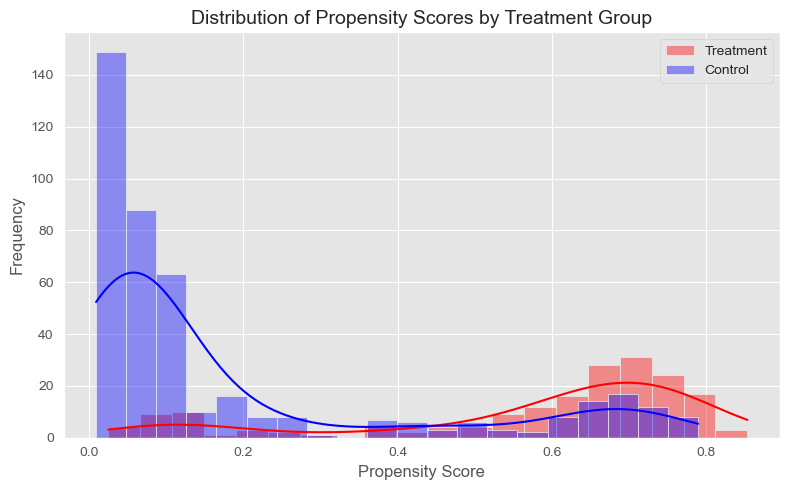

In [52]:
plt.figure(figsize=(8, 5))

# Treatment group
sns.histplot(pscore_logit[lalonde_df['treat'] == 1], bins=20, color='red', alpha=0.4, kde=True,label = 'Treatment')
sns.histplot(pscore_logit[lalonde_df['treat'] == 0], bins=20, color='blue', alpha=0.4, kde=True, label = 'Control')

plt.title('Distribution of Propensity Scores by Treatment Group', fontsize=14)
plt.xlabel('Propensity Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

-------

### Matching using $k$-nearest neighbors

We are going to match each treated subject with a control subject using nearest neighbors matching on the estimated propensity score. Here, we use another popular clustering algorithm: the **$k$-nearest neighbors ($k$-NN) algorithm**. This algorithm is quite similar to the one we used in Case 7.5. However, instead of finding the single control individual with the closest propensity score, it finds the $k$ control individuals with the closest propensity scores. The use of $k>1$ is handy for classification purposes: if each individual lies in a category, we can classify a new individual by finding its $k$ nearest neighbors and use the most common category of its neighbors as the selected category for the new individual. 

<h3>Exercise 4 :</h3>
<p>In this exercise, we will use the <code>sklearn.neighbors</code> function <a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors.kneighbors"><code>NearestNeighbors</code></a> to find, for each subject in the treatment group, the $k=5$ subjects in the control group with the closest propensity scores.</p>
<h4>4.1</h4>
<p>Separate the propensity scores <code>pscore_logit</code> found in Exercise 3 for treatment and control groups. Call these <code>treat_pscores</code> and <code>control_pscores</code> respectively. Use the <code>control_pscores</code> to train a $k$-NN algorithm with $k=5$.</p>
<p><strong>Hint:</strong> Load the model using <code>knn = neighbors.NearestNeighbors(n_neighbors=5,metric='euclidean')</code>. You may want to reshape the control scores using <code>control_pscores.reshape(-1,1)</code>.</p>

**Answer.**

In [57]:
treat_pscores = pscore_logit[lalonde_df['treat'] == 1].values.reshape(-1, 1)
control_pscores = pscore_logit[lalonde_df['treat'] == 0].values.reshape(-1, 1)

knn = neighbors.NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(control_pscores)

NearestNeighbors(metric='euclidean')

-------

<h4>4.2</h4>
<p>Find the indices of the five nearest neighbors using the method <code>.kneighbors()</code> applied to <code>treat_pscores</code>. </p>

**Answer.**

In [61]:
distances, indices = knn.kneighbors(treat_pscores.reshape(-1, 1))

#Observe the indices of the five nearest neighbours for the first five individuals in the treatment group
indices[:5]

array([[ 68, 386, 372, 385, 375],
       [110,  65, 338, 149, 198],
       [369, 188, 267, 380, 354],
       [225, 195, 117, 387, 411],
       [139, 133, 276, 217, 371]])

-------

<h4>4.3</h4>
<p>Match the treatment and control groups using the closest of the five neighbors found above. Your output should be a pair of <code>DataFrames</code>, each with $185$ rows from the <code>lalonde_df</code>. The first should correspond to the treatment group and the second should correspond to the matched control group.</p>

**Answer.**

In [65]:
control = lalonde_df[lalonde_df['treat']==0]

closest_neighbour = indices[:,0]

matched_treatment = lalonde_df[lalonde_df['treat'] == 1].reset_index(drop=True)
matched_control = control.iloc[closest_neighbour].reset_index(drop=True)

#Adding Propensity score to the dfs
matched_treatment['p_score'] = pscore_logit[lalonde_df['treat'] == 1].reset_index(drop=True).values
matched_control['p_score'] = pscore_logit[lalonde_df['treat'] == 0].reset_index(drop=True).values[closest_neighbour]

In [66]:
matched_treatment.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,p_score
0,1,37,11,1,0,1,1,0.0,0.0,9930.0460,0.638770
1,1,22,9,0,1,0,1,0.0,0.0,3595.8940,0.224634
2,1,30,12,1,0,0,0,0.0,0.0,24909.4500,0.678244
3,1,27,11,1,0,0,1,0.0,0.0,7506.1460,0.776324
4,1,33,8,1,0,0,1,0.0,0.0,289.7899,0.701639


In [67]:
matched_control.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,p_score
0,0,30,17,1,0,0,0,17827.37000,5546.4190,14421.1300,0.638554
1,0,51,11,0,0,0,1,48.98167,3813.3870,1525.0140,0.224079
2,0,16,9,1,0,0,1,0.00000,0.0000,2158.9590,0.678789
3,0,39,10,1,0,0,1,844.44400,889.7903,701.9201,0.778912
4,0,19,9,1,0,0,1,1079.55600,2873.4680,14344.2900,0.705085


-------

<h3>Propensity score distribution plot after matching</h3>
<p>Let's take a glance at the distribution of propensity score after matching. Both groups have similar distributions on the propensity score. This means we have reach a balance in both groups. This enables us to further analyze the causality effect of the treatment.</p>

<h3>Exercise 5 :</h3>
<p>Make a plot which shows the histograms of propensity scores for the control and treatment groups after matching. Compare your results with the plot in Exercise 3.2.</p>

**Answer.**

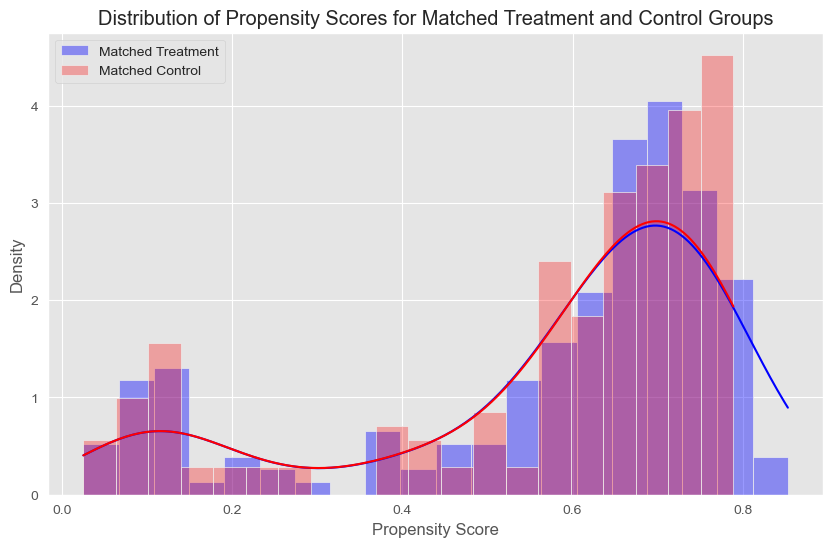

In [72]:
# Plotting Distribution of Propensity Scores after Matching
plt.figure(figsize=(10, 6))

# Matched treatment group
sns.histplot(matched_treatment['p_score'], kde=True, color='blue', alpha=0.4, label='Matched Treatment', stat='density', bins=20)

# Matched control group
sns.histplot(matched_control['p_score'], kde=True, color='red', alpha=0.3, label='Matched Control', stat='density', bins=20)

# Adding labels and title
plt.title('Distribution of Propensity Scores for Matched Treatment and Control Groups')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.show()

We have plotted the distribution of propensity scores for the matched treatment and control groups. After matching, the distributions of the propensity scores are much more similar. This implies there is an improved balance between the groups. In contrast, before matching, the propensity score distributions were uneven, suggesting significant differences between the treatment and control groups.

This improved balance helps reduce confounding factors, which allows us to obtain a clearer and more reliable estimation of the program's (treatment) effects.

-------

<h3>Exercise 6 :</h3>

Assess covariate balance after the $k$-NN matching.  For this, compute the absolute standardized differences in means in the covariates after matching,  $$ASMD_a(x)=\frac{\bar{x}_{t,a}-{\bar{x}_{c,a}}}{\sqrt{\frac{s^{2}_{t,b} + s^{2}_{c,b}}{2}}},$$ where $\bar{x}_{t,a}$ and $\bar{x}_{c,a}$ are, respectively, the means of covariate $x$ in the treatment and control groups after matching, and $s^{2}_{t,b}$ and $s^{2}_{c,b}$ are, correspondingly, the sample variances treatment and control groups before matching. 

One reason to use the sample variances before matching rather than the sample variances after matching is to free the comparisons of the means after matching from simultaneous changes in the variances. Comment on covariate balance.

**Answer.**

In [77]:
features = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78'] 

for feat in features:
    matched_treatmentMean = matched_treatment[feat].mean()
    matched_controlMean = matched_control[feat].mean()

    treatment_VarB = lalonde_df.loc[lalonde_df['treat'] == 1][feat].var()
    control_VarB = lalonde_df.loc[lalonde_df['treat'] == 0][feat].var()

    denom = np.sqrt((treatment_VarB + control_VarB)/2)
    Asmd = np.abs((matched_treatmentMean - matched_controlMean)/denom)

    if Asmd < 0.1:
        print(f'ASMD for {feat}: {Asmd} - Randomized')
    elif (0.1<Asmd<0.2):
        print(f'ASMD for {feat}: {Asmd} - Slightly Imbalanced')
    elif Asmd > 0.2:
        print(f'ASMD for {feat}: {Asmd} - Severely Imbalanced')

ASMD for age: 0.1872126802863005 - Slightly Imbalanced
ASMD for educ: 0.013134145374003401 - Randomized
ASMD for black: 0.014075653068096007 - Randomized
ASMD for hispan: 0.01809428676533664 - Randomized
ASMD for married: 0.13218931558924024 - Slightly Imbalanced
ASMD for nodegree: 0.011408041611194505 - Randomized
ASMD for re74: 0.04072754064985129 - Randomized
ASMD for re75: 0.008638775000544396 - Randomized
ASMD for re78: 0.2569235070565138 - Severely Imbalanced


After matching, most covariates - *education, black, hispan, nodegree, re74* and *re75* - are well-balanced. Specifically the balance of covariates *black* and *nodegree* have improved significantly. However, the balance of covariates *age* and *married* are now slightly imbalanced.
We can observe that after matching, the overall covariate balance has improved. 

Furthermore, the covariate balance of *re78* has become severely imbalanced. This is an especially important observation. This may suggest that the program does have an impact as there is a difference in earnings between the treatment and control groups. Further analysis is required to determine whether the treatment had a positive or negative impact.

-------

<h3>Exercise 7 :</h3>
<p>Estimate the average effect of treatment on <font color='red'> wages (<code>re78</code>) </font> after matching. What do you conclude?</p>

**Answer.**

In [82]:
matched_treatment.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,p_score
0,1,37,11,1,0,1,1,0.0,0.0,9930.0460,0.638770
1,1,22,9,0,1,0,1,0.0,0.0,3595.8940,0.224634
2,1,30,12,1,0,0,0,0.0,0.0,24909.4500,0.678244
3,1,27,11,1,0,0,1,0.0,0.0,7506.1460,0.776324
4,1,33,8,1,0,0,1,0.0,0.0,289.7899,0.701639


In [83]:
matched_control.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,p_score
0,0,30,17,1,0,0,0,17827.37000,5546.4190,14421.1300,0.638554
1,0,51,11,0,0,0,1,48.98167,3813.3870,1525.0140,0.224079
2,0,16,9,1,0,0,1,0.00000,0.0000,2158.9590,0.678789
3,0,39,10,1,0,0,1,844.44400,889.7903,701.9201,0.778912
4,0,19,9,1,0,0,1,1079.55600,2873.4680,14344.2900,0.705085


In [84]:
matchedmeanT = np.mean(matched_treatment['re78'].values)
matchedmeanC = np.mean(matched_control['re78'].values)

averageEffect = matchedmeanT - matchedmeanC

round(averageEffect,2)

1949.07

After matching individuals in the treatment and control group, we found the average difference in earnings in 1978, (*re78*), was `$1949.07`.
This suggests that the treatment (Training program) had a positive impact on the individuals in the treatment program. On average, their earnings were better by $1949.07. 

Although we cannot definitively prove/conclude that the program directly caused the increased average salary, the program likely played a significant role. The matching process has reduced confounding factors which makes our conclusion more likely. 

-------

<h2>Propensity score matching using decision trees and random forests</h2>

<h3>Exercise 8 :</h3>
<p>To validate our propensity score calculations, let's try calculating them using other models such as decision trees and random forests.</p>

<h4>8.1</h4>
<p>Build a decision tree regressor where the outcome variable is whether a subject was in the treatment group or not, and the covariates are all the other variables except <code>re78</code>. Use the <code>sklearn.tree</code> function <code>DecisionTreeRegressor(max_depth=4)</code> and call the new propensity scores <code>pscore_tree</code>.</p>

**Answer.**

In [91]:
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

df_t = lalonde_df.copy()

tree_model = tree.DecisionTreeRegressor(max_depth=4)
tree_model = tree_model.fit(df_t[covariates], df_t['treat'])

pscore_tree = tree_model.predict(df_t[covariates])

-------

<h4>8.2</h4>
<p>Plot the decision tree regressor using the code</p>
<div class="codehilite"><pre><span></span><code><span class="err">fig = plt.gcf()</span>
<span class="err">fig.set_size_inches(150, 100)</span>
<span class="err">tree.plot_tree(dt,filled=True,feature_names=cleaned_df.columns)</span>
<span class="err">fig.savefig(&#39;tree.png&#39;)</span>
</code></pre></div>


<p>Replace <code>dt</code> with the name of the model created in Exercise 8.1. Use the plot to estimate the probability that a 24 year old, single, uneducated Hispanic individual that earned $\$20000$ in 1974 was enrolled in the employment program. Do the same with a black man with the same characteristics. (Assume that there were no black Hispanics in the study.)</p>

**Answer.**

In [95]:
fig = plt.gcf()
fig.set_size_inches(150, 100)
tree.plot_tree(tree_model,filled=True,feature_names=covariates)
fig.savefig('tree.png')

We will use the above plot to estimate the probability that a 24-year-old, single, uneducated Hispanic individual who earned \$20,000 in 1974 was enrolled in the program. 

* **Level Zero (Root Node):** Since the individual is Hispanic (and assuming no Black Hispanics), the statement is true, so we move to the *Left* inner node.
* **First level:** Since the individual earned `$20,000`, which is greater than `$16,654`, the statement is false, so we follow the *Right* inner node.
*  **Second Level:** Since the individual is 24, which is greater than 23.5, the statement is false, we follow the *Right* inner node.
* **Third Level:** Since the individual is uneducated, the statement (educ <= 12.5) is true, so we follow the *Left* inner node.
* We come to the result/leaf where **`value = 0`**. This implies that this individual has a **0% probability** of being in the treatment group (being enrolled in the program). 

Similarly, we will use the above plot to estimate the probability that a 24-year-old, single, uneducated Black man who earned \$20,000 in 1974 was enrolled in the program. 

* **Level Zero (Root Node):** Since the individual is Black, the statement is false, so we move to the *Right* inner node.
* **First level:** Since the individual earned `$20,000`, which is less than `$48,002`, the statement is true, so we follow the *Left* inner node.
* **Second Level:** Since the individual is 24, which is greater than 20.5, the statement is false, so we follow the *Right* inner node.
* **Third Level:** Since the individual is 24, which is less than 49.5, the statement is true, so we follow the *Left* inner node.
* We come to the result/leaf where **`value = 0.865`**. This implies that this individual has a **86.5% probability** of being in the treatment group (being enrolled in the program). 

-------

<h4>8.3</h4>
<p>Estimate the propensity scores now by using random forests. For the model, use the <code>sklearn.ensemble</code> function <code>RandomForestClassifier</code> with parameters <code>n_estimators=100, max_depth=4, random_state=42</code>. Then, use the method <code>predict_proba</code> to extract the propensity scores. Name the scores <code>pscore_forest</code>.</p>

**Answer.**

In [100]:
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

dfRF = lalonde_df.copy()

rf_model = ensemble.RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(dfRF[covariates], dfRF['treat'])
pscore_forest = rf_model.predict_proba(dfRF[covariates])[:,1]

-------

<h4>8.4</h4>
<p>Make a plot with the three ROC curves corresponding to the logistic regression, decision tree, and random forest classifiers used to compute the propensity scores. What is the AUC of each model? Which model <em>seems</em> to do the best job?</p>

**Answer.**

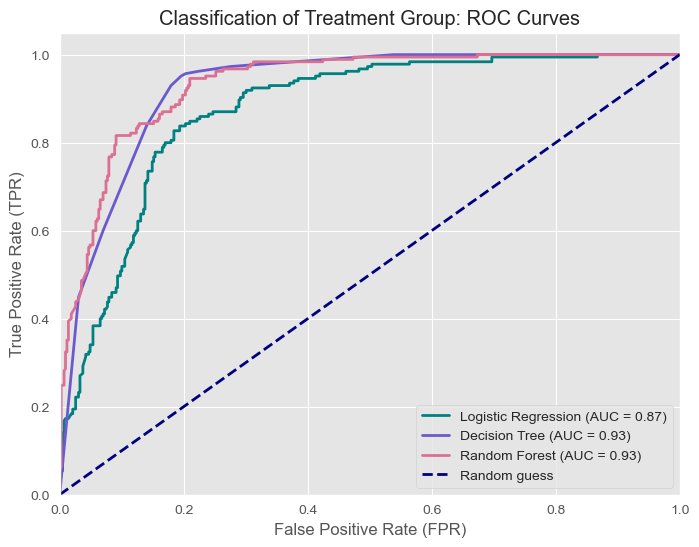

In [104]:
# Logistic Regression ROC/AUC
fprL, tprL, thresholds = metrics.roc_curve(log_model['treat'], pscore_logit)
roc_aucL = metrics.auc(fprL, tprL)

# Decision Tree ROC/AUC
fprT, tprT, thresholds = metrics.roc_curve(df_t['treat'], pscore_tree)
roc_aucT = metrics.auc(fprT, tprT)

# Random Forest ROC/AUC
roc_pF = metrics.roc_curve(df_t['treat'], pscore_forest)
auc_pF = metrics.auc(roc_pF[0], roc_pF[1])


# Plot ROC Curves for all models on the same plot
plt.figure(figsize=(8, 6))

plt.plot(fprL, tprL, color='teal', lw=2, label=f'Logistic Regression (AUC = {roc_aucL:.2f})')
plt.plot(fprT, tprT, color='slateblue', lw=2, label=f'Decision Tree (AUC = {roc_aucT:.2f})')
plt.plot(roc_pF[0], roc_pF[1], color='palevioletred', lw=2, label=f'Random Forest (AUC = {auc_pF:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Classification of Treatment Group: ROC Curves')
plt.legend(loc='lower right')

plt.show()

The AUC of each of the models are:
* Logistic Regression: AUC = 0.87
* Decision Tree: AUC = 0.93
* Random Forest: AUC = 0.93

Looking simply at the AUC scores, the decision tree and random forest models are the better models with AUC scores of 0.93. 

Looking at the graph, it appears the decision tree model has less variability since the curve appears smoother than the random forest model. Thus, I would claim the decision tree model *seems* the best. 

-------

<h4>8.5</h4>
<p>Consider the following statement:</p>
<blockquote>
<p>"<em>A model with a higher AUC provides much better estimates of the true propensity scores. In particular, a matching using the propensity scores of such a model will balance the covariates much better.</em>"</p>
</blockquote>
<p>Is the statement true or false? Explain. </p>

**Answer.**

This statement is **false**.

The AUC does not specifically provide better estimates of the true propensity scores. 
* Propensity scores are the output from the model. It is the probability of an individual enrolling in the program based on their covariates.
* The AUC score evaluates how well the model performs while classifying individuals between the treatment and control groups based on the individual's covariates. The AUC score does not determine how accurate the propensity scores are.

Imagine a model has a high AUC score, this implies that the model performs a good job at classifying individuals in the treatment and control groups. However, since the AUC score does not demonstrate the accuracy of propensity scores, also imagine the propensity scores are inaccurate. Since our matching process depends on the accuracy of propensity score (implies similar characteristics), this would imply that the matching of individuals between the groups will be inaccurate. If the matching is inaccurate, this defeats the purpose of completing the matching and the covariates will still be imbalanced. 

-------

<h4>8.6</h4>
<p>Repeat the matching procedure now with the estimated propensity scores <code>pscore_tree</code> and <code>pscore_forest</code>. Assess the covariate balances and estimate the average effect of treatment on wages (<code>re78</code>) after matching. Compare your results. </p>

**Answer.**

In [113]:
#Decision Tree

control = lalonde_df[lalonde_df['treat']==0]

treat_pscores_tree = pscore_tree[lalonde_df['treat'] == 1]  
control_pscores_tree = pscore_tree[lalonde_df['treat'] == 0].reshape(-1, 1)

knn_tree = neighbors.NearestNeighbors(n_neighbors=1, metric='euclidean')
knn_tree.fit(control_pscores_tree)

distancesT, indicesT = knn_tree.kneighbors(treat_pscores_tree.reshape(-1, 1))

closest_neighbourT = indicesT[:,0]

matched_treatmentT = lalonde_df[lalonde_df['treat']==1].reset_index(drop=True)
matched_controlT = control.iloc[closest_neighbourT].reset_index(drop=True)

matched_treatmentT["pscore_tree"] = pd.Series(treat_pscores_tree).reset_index(drop=True)
matched_controlT["pscore_tree"] = pd.Series(control_pscores_tree[closest_neighbourT].flatten()).reset_index(drop=True)

matched_treatmentT.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,pscore_tree
0,1,37,11,1,0,1,1,0.0,0.0,9930.0460,0.864583
1,1,22,9,0,1,0,1,0.0,0.0,3595.8940,0.500000
2,1,30,12,1,0,0,0,0.0,0.0,24909.4500,0.864583
3,1,27,11,1,0,0,1,0.0,0.0,7506.1460,0.864583
4,1,33,8,1,0,0,1,0.0,0.0,289.7899,0.864583


In [114]:
matched_controlT.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,pscore_tree
0,0,26,12,1,0,0,0,0.0,1448.371,0.0,0.864583
1,0,20,13,0,0,0,0,0.0,2352.484,0.0,0.500000
2,0,26,12,1,0,0,0,0.0,1448.371,0.0,0.864583
3,0,26,12,1,0,0,0,0.0,1448.371,0.0,0.864583
4,0,26,12,1,0,0,0,0.0,1448.371,0.0,0.864583


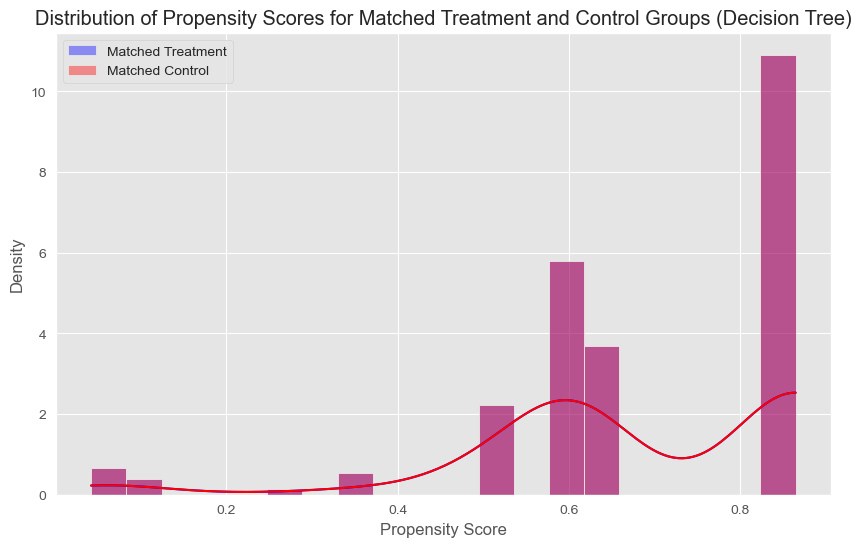

In [115]:
#Plotting Distribution of Propensity scores after matching
plt.figure(figsize=(10, 6))

# Matched treatment group
sns.histplot(matched_treatmentT['pscore_tree'], kde=True, color='blue', alpha = 0.4, label='Matched Treatment', stat='density', bins=20)

# Matched control group
sns.histplot(matched_controlT['pscore_tree'], kde=True, color='red', alpha = 0.4, label='Matched Control', stat='density', bins=20)

plt.title('Distribution of Propensity Scores for Matched Treatment and Control Groups (Decision Tree)')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()

plt.show()

In [116]:
#Random Forest
control = lalonde_df[lalonde_df['treat']==0]

treat_pscoresF = pscore_forest[lalonde_df['treat'] == 1] .reshape(-1, 1)
control_pscoresF = pscore_forest[lalonde_df['treat'] == 0].reshape(-1, 1)

knnF = neighbors.NearestNeighbors(n_neighbors=1, metric='euclidean')
knnF.fit(control_pscoresF)

distancesF, indicesF = knnF.kneighbors(treat_pscoresF)

closest_neighbourF = indicesF[:,0]

matched_treatmentF = lalonde_df[lalonde_df['treat']==1].reset_index(drop=True)
matched_controlF = control.iloc[closest_neighbourF].reset_index(drop=True) 

matched_treatmentF["pscore_F"] = pd.Series(treat_pscores_tree).reset_index(drop=True)
matched_controlF["pscore_F"] = pd.Series(control_pscores_tree[closest_neighbourT].flatten()).reset_index(drop=True)

matched_treatmentF.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,pscore_F
0,1,37,11,1,0,1,1,0.0,0.0,9930.0460,0.864583
1,1,22,9,0,1,0,1,0.0,0.0,3595.8940,0.500000
2,1,30,12,1,0,0,0,0.0,0.0,24909.4500,0.864583
3,1,27,11,1,0,0,1,0.0,0.0,7506.1460,0.864583
4,1,33,8,1,0,0,1,0.0,0.0,289.7899,0.864583


In [117]:
matched_controlF.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,pscore_F
0,0,40,11,1,0,1,1,0.0000,0.000,0.0000,0.864583
1,0,25,12,1,0,1,0,295.8493,6942.871,461.0507,0.500000
2,0,27,10,1,0,0,1,0.0000,0.000,7543.7940,0.864583
3,0,27,10,1,0,0,1,0.0000,0.000,7543.7940,0.864583
4,0,34,12,1,0,0,0,0.0000,0.000,0.0000,0.864583


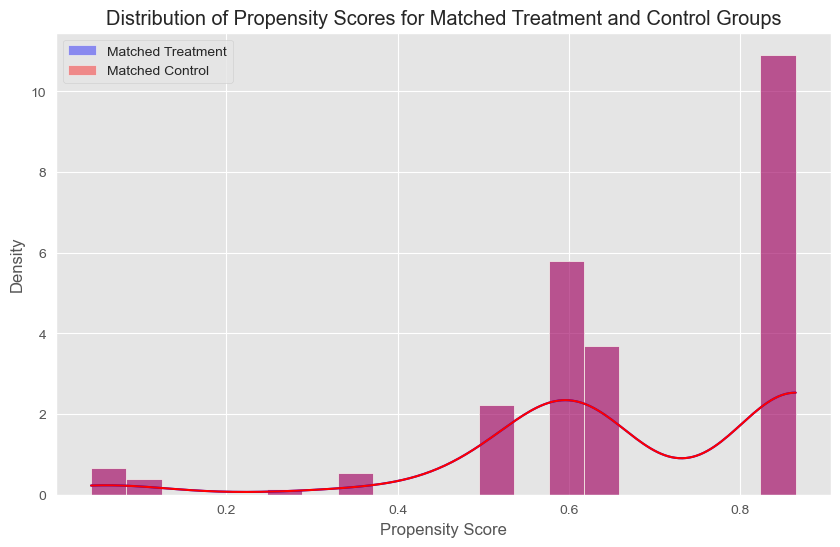

In [118]:
#PLOTTING DISTRIBUTION OF PROPENSITY SCORES

plt.figure(figsize=(10, 6))

# Matched Treatment group
sns.histplot(matched_treatmentF['pscore_F'], kde=True, color='blue',alpha = 0.4, label='Matched Treatment', stat='density', bins=20)

# Matched control group
sns.histplot(matched_controlF['pscore_F'], kde=True, color='red',alpha = 0.4, label='Matched Control', stat='density', bins=20)


plt.title('Distribution of Propensity Scores for Matched Treatment and Control Groups')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()

# Show plot
plt.show()

In [119]:
#CoVariant Imbalance Check - Decision Tree
features = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78']
for feat in features:
    matched_treatmentMeanT = matched_treatmentT[feat].mean()
    matched_controlMeanT = matched_controlT[feat].mean()

    treatment_VarBT = lalonde_df.loc[lalonde_df['treat'] == 1][feat].var()
    control_VarBT = lalonde_df.loc[lalonde_df['treat'] == 0][feat].var()

    denomT = np.sqrt((treatment_VarBT + control_VarBT)/2)
    AsmdT = np.abs((matched_treatmentMeanT - matched_controlMeanT)/denomT)

    if AsmdT < 0.1:
        print(f'ASMD for {feat}: {AsmdT} - Randomized')
    elif (0.1<AsmdT<0.2):
        print(f'ASMD for {feat}: {AsmdT} - Slightly Imbalanced')
    elif AsmdT > 0.2:
        print(f'ASMD for {feat}: {AsmdT} - Severely Imbalanced')

ASMD for age: 0.340171936419272 - Severely Imbalanced
ASMD for educ: 0.6326280021811528 - Severely Imbalanced
ASMD for black: 0.0 - Randomized
ASMD for hispan: 0.19903715441870304 - Slightly Imbalanced
ASMD for married: 0.2163097891460295 - Severely Imbalanced
ASMD for nodegree: 1.1065800362858784 - Severely Imbalanced
ASMD for re74: 0.08653760426322482 - Randomized
ASMD for re75: 0.42069771387295624 - Severely Imbalanced
ASMD for re78: 0.46662963801855417 - Severely Imbalanced


In [120]:
#CoVariant Imbalance Check - Random Forest
for feat in features:
    matched_treatmentMeanF = matched_treatmentF[feat].mean()
    matched_controlMeanF = matched_controlF[feat].mean()

    treatment_VarBF = lalonde_df.loc[lalonde_df['treat'] == 1][feat].var()
    control_VarBF = lalonde_df.loc[lalonde_df['treat'] == 0][feat].var()

    denomF = np.sqrt((treatment_VarBF + control_VarBF)/2)
    AsmdF = np.abs((matched_treatmentMeanF - matched_controlMeanF)/denomF)

    if AsmdF < 0.1:
        print(f'ASMD for {feat}: {AsmdF} - Randomized')
    elif (0.1<AsmdF<0.2):
        print(f'ASMD for {feat}: {AsmdF} - Slightly Imbalanced')
    elif AsmdF > 0.2:
        print(f'ASMD for {feat}: {AsmdF} - Severely Imbalanced')

ASMD for age: 0.12992678127124974 - Slightly Imbalanced
ASMD for educ: 0.05253658149601289 - Randomized
ASMD for black: 0.15483218374905436 - Slightly Imbalanced
ASMD for hispan: 0.10856572059201984 - Slightly Imbalanced
ASMD for married: 0.10815489457301475 - Slightly Imbalanced
ASMD for nodegree: 0.13689649933433548 - Slightly Imbalanced
ASMD for re74: 0.12379775956497982 - Slightly Imbalanced
ASMD for re75: 0.20884361063321832 - Severely Imbalanced
ASMD for re78: 0.09014203009836966 - Randomized


In [121]:
averageT=  (matched_treatmentT['re78'] - matched_controlT['re78']).mean()
print("Average Effect (Decision Tree): " + str(round(averageT,2)))
averageF = (matched_treatmentF['re78'] -matched_controlF['re78']).mean()
print("Average Effect (Random Forest): " + str((round(averageF,2))))

Average Effect (Decision Tree): 3539.95
Average Effect (Random Forest): 683.84


After matching we can say the following for the covariant balance in the Decision Tree model:
* Only the variables *black* and *re74* are randomized
* All other variables -  *age, education, married, nodegree, re75* and *re78* - are severely imbalanced, while *hispan* is slightly imbalanced
* This model does poorly in balancing the covariates since many features are **severely** imbalanced.

After matching we can say the following for the covariant balance in the random forest model:
* Only the variables: *education* and *re78* are randomized.
* All other variables - *age, black, hispan, married, nodegree* and *re74* - are slightly imbalanced, while *re75* is severely imbalanced.
* This model also does not balance all features extremely well; however, most are only slightly imbalanced. This matching process makes a good effort to balance all features.

These models indicate that the treatment has a positive average effect on the individuals in the treatment group (enrolled in the program).

The Decision Tree model estimates that the individuals in the treatment group earn, on average, `$3539.95` more than those in the control group. 


The random forest model estimates that the individuals in the treatment group earn, on average, `$683.84` more than those in the control group. 

These two models have a large discrepancy. The decision tree model suggests that the treatment has a significantly larger effect than the random forest model. Due to the significant imbalance of covariates in the decision tree model, this result may be unreliable. 

-------

<h4>8.7</h4>
<p>Why do you think the decision tree regressor performed badly on balancing the covariates of the treat and control groups?  </p>
<p><strong>Hint:</strong> Look at the distances of the ten nearest neighbors output by <code>.kneighbors()</code> for the propensity scores of the decision tree model. What do you see? Why do you think these distances may have an impact on balancing?</p>

**Answer.**

-------

In [128]:
treatTC = pscore_tree[lalonde_df['treat'] == 1]  
controlTC = pscore_tree[lalonde_df['treat'] == 0].reshape(-1, 1)

knnT= neighbors.NearestNeighbors(n_neighbors=5, metric='euclidean')
knnT.fit(controlTC)

distancesTC, indicesTC = knnT.kneighbors(treatTC.reshape(-1, 1))


for i in range(10):
    print(f"Distances for matched individual {i+1}: {distances[i]}")


Distances for matched individual 1: [0.00021577 0.00301606 0.00412295 0.00412295 0.00749939]
Distances for matched individual 2: [0.00055488 0.00203913 0.00843858 0.01176145 0.01325217]
Distances for matched individual 3: [0.00054473 0.00311312 0.00376988 0.00420012 0.00483948]
Distances for matched individual 4: [0.00258745 0.01218949 0.01284875 0.0226777  0.02445873]
Distances for matched individual 5: [0.00344627 0.00495839 0.0076749  0.00816212 0.00924833]
Distances for matched individual 6: [0.00559328 0.00601511 0.00667948 0.00721162 0.00746819]
Distances for matched individual 7: [0.00192223 0.00328541 0.00387303 0.00406627 0.00565025]
Distances for matched individual 8: [0.00055028 0.01081157 0.02558852 0.03607673 0.03785776]
Distances for matched individual 9: [0.00092671 0.00933459 0.01570366 0.02619187 0.0279729 ]
Distances for matched individual 10: [8.75104693e-05 1.23169787e-04 7.29687694e-04 8.58538425e-04
 8.92571566e-04]


In the above analysis, we have printed the distances of the five closest neighbours for the first 10 individuals in the treatment group. 
We can observe that the distances are inconsistent - some are small, and others are significantly larger. For instance, the distance between individual 10 and their second closest neighbour is 0.000123169787. However, the distance between individual 8 and their second closest neighbour is 0.01081157. his large difference in distances between matched pairs suggests that the matching process may not work effectively.

The purpose of KNN matching is to pair individuals in the treatment group with individuals in the control group who have similar propensity scores. This ensures the covariates are more balanced between the two groups. However, if the distance between pairs is inconsistent, the propensity scores are not well-matched, which will lead to imbalanced covariates. Poorly matched propensity scores imply that their covariates are not well balanced. This defeats the purpose of the matching process. Our conclusion/observations about the treatment program will still be impacted by confounding factors.